In [1]:
import torch.optim as optim
from src.utils import *
from src.algorithms import *
from src.losses import *
import deepinv as dinv
from pathlib import Path
import torch
import matplotlib.pyplot as plt
from deepinv.models import DRUNet
from deepinv.optim.data_fidelity import L2
#from deepinv.optim.prior import PnP, ZeroPrior
from deepinv.optim import PGD
from deepinv.utils import load_example
from deepinv.utils.plotting import plot
from deepinv.optim.phase_retrieval import (
    correct_global_phase,
)
from deepinv.models.complex import to_complex_denoiser
from deepinv.optim.prior import PnP
import time
import numpy as np


BASE_DIR = Path(".")
RESULTS_DIR = BASE_DIR / "results"
# Set global random seed to ensure reproducibility.
torch.manual_seed(0)

import torch
import time
import numpy as np
import deepinv.optim.prior as prior

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [2]:
# Image size
img_size = 32
# The pixel values of the image are in the range [0, 1].
x = load_example(
    "SheppLogan.png",
    img_size=img_size,
    grayscale=True,
    resize_mode="resize",
    device=device,
)
print(x.min(), x.max())

tensor(0., device='cuda:0') tensor(0.7412, device='cuda:0')


In [3]:
x_phase = torch.exp(1j * x * torch.pi - 0.5j * torch.pi)

# Every element of the signal should have unit norm.
assert torch.allclose(x_phase.real**2 + x_phase.imag**2, torch.tensor(1.0))

In [4]:
# Define physics information
oversampling_ratio = 5.0
img_size = x.shape[1:]
m = int(oversampling_ratio * torch.prod(torch.tensor(img_size)))
n_channels = 1  # 3 for color images, 1 for gray-scale images

# Create the physics
physics = dinv.physics.RandomPhaseRetrieval(
    m=m,
    img_size=img_size,
    device=device,
)

# Generate measurements
y = physics(x_phase)

In [5]:
num_iter = 1000
x_true = x_phase.clone().detach()

[0] loss=29.6514  ||x_k-x*||^2=193.1519  lr=0.100000
[100] loss=1.2607  ||x_k-x*||^2=52.9498  lr=0.100000
[200] loss=0.4431  ||x_k-x*||^2=22.8376  lr=0.100000
[300] loss=0.1832  ||x_k-x*||^2=11.1352  lr=0.100000
[400] loss=0.0907  ||x_k-x*||^2=5.8181  lr=0.100000
[500] loss=0.0444  ||x_k-x*||^2=3.1779  lr=0.100000
[600] loss=0.0242  ||x_k-x*||^2=1.8026  lr=0.100000
[700] loss=0.0133  ||x_k-x*||^2=1.0556  lr=0.100000
[800] loss=0.0080  ||x_k-x*||^2=0.6323  lr=0.100000
[900] loss=0.0047  ||x_k-x*||^2=0.3851  lr=0.100000
SGD initial loss: 29.651428
SGD final loss:   0.002896
SGD total time:   3.1506 sec
SGD avg/iter:     0.003151 sec


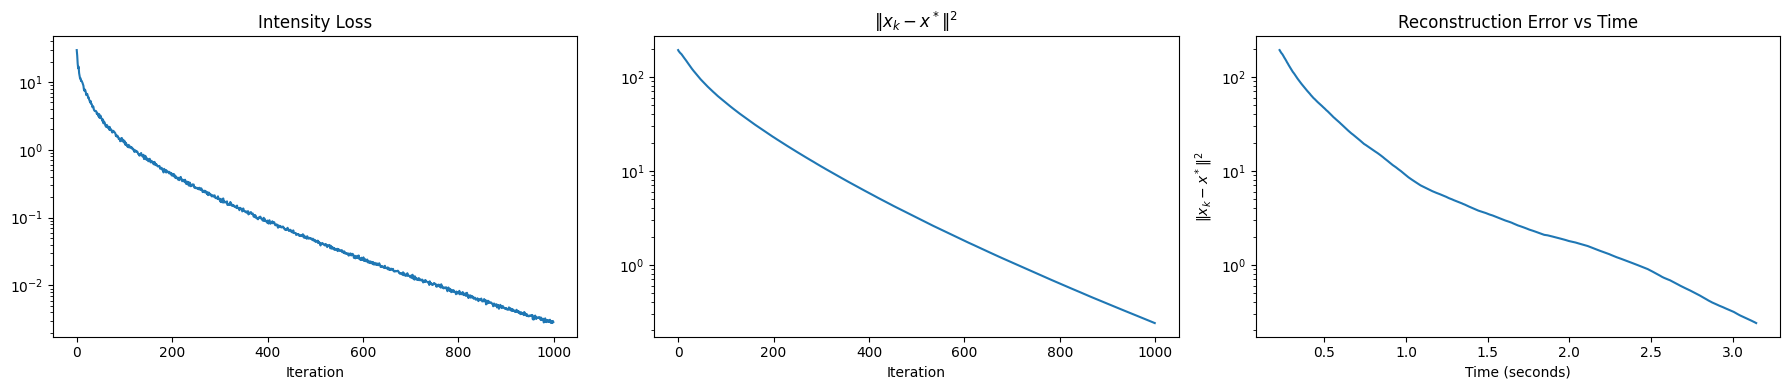

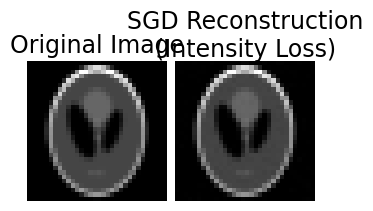

SGD Final Loss:          0.002896
SGD Final ||x_k-x*||^2:  0.239612


In [6]:
x_init = physics.A_dagger(y, n_iter=300).clone().detach()

result_sgd = stochastic_gradient_descent_torch(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    num_iter=1000,
    step_size=1e-1,
    batch_ratio=0.3,
    step_mode="constant",
    loss_type="intensity",
    optimizer_type="sgd",
    momentum=0.0,
    verbose=True
)

loss_hist = result_sgd["loss_hist"]
recon_error_hist = result_sgd["recon_error_hist"]
time_hist = result_sgd["time_hist"]
x_final = result_sgd["x_final"]

print_run_summary(
    loss_hist,
    result_sgd["total_time"],
    result_sgd["avg_time"],
    method_name="SGD"
)

plot_metrics(loss_hist, recon_error_hist, time_hist, loss_name="Intensity Loss")

x_sgd_corrected = correct_global_phase(x_final, x_true)
x_sgd_recon = torch.angle(x_sgd_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_sgd_recon,
    title_recon="SGD Reconstruction (Intensity Loss)"
)

final_recon_error = print_final_metrics(
    x_sgd_corrected,
    x_true,
    loss_hist,
    method_name="SGD"
)

GD semi-log convergence estimate
Fit range         : [301, 1000]
slope             : -5.439541e-03
rho = exp(slope)  : 0.994575
C                 : 5.015195e+01
R^2               : 0.997862
ratio mean        : 0.994523
ratio median      : 0.994640
ratio std         : 0.000641
model             : e_k ≈ C * rho^k


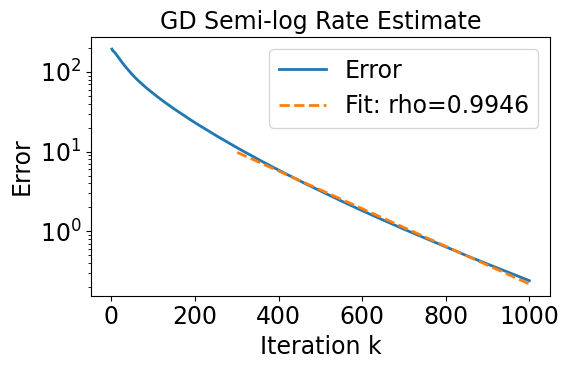

In [7]:
gd_rate = estimate_semilog_rate(
    error_hist=result_sgd["recon_error_hist"],
    start_ratio=0.3,
    end_ratio=1,
    method_name="GD",
    plot=True
)

[0] loss=24.6194  ||x_k-x*||^2=193.5085  lr=0.100000
[100] loss=1.2424  ||x_k-x*||^2=27.3161  lr=0.100000
[200] loss=0.2198  ||x_k-x*||^2=6.3331  lr=0.100000
[300] loss=0.0522  ||x_k-x*||^2=1.6773  lr=0.100000
[400] loss=0.0148  ||x_k-x*||^2=0.4887  lr=0.100000
[500] loss=0.0041  ||x_k-x*||^2=0.1533  lr=0.100000
[600] loss=0.0014  ||x_k-x*||^2=0.0516  lr=0.100000
[700] loss=0.0005  ||x_k-x*||^2=0.0180  lr=0.100000
[800] loss=0.0002  ||x_k-x*||^2=0.0065  lr=0.100000
[900] loss=0.0001  ||x_k-x*||^2=0.0024  lr=0.100000
SGD initial loss: 24.619394
SGD final loss:   0.000022
SGD total time:   2.7392 sec
SGD avg/iter:     0.002739 sec


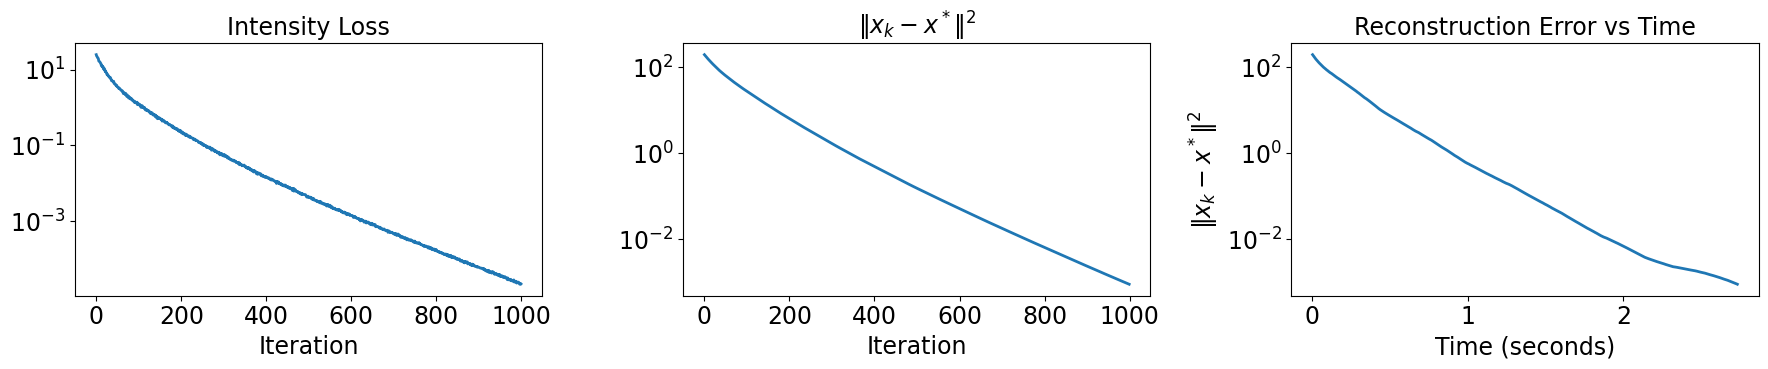

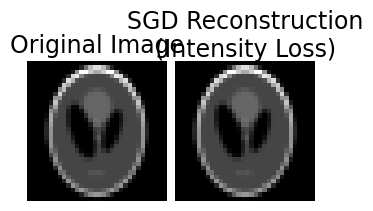

SGD Final Loss:          0.000022
SGD Final ||x_k-x*||^2:  0.000909


In [8]:
x_init = physics.A_dagger(y, n_iter=300).clone().detach()

result_sgd = stochastic_gradient_descent_torch(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    num_iter=1000,
    step_size=1e-1,
    batch_ratio=0.3,
    step_mode="constant",
    loss_type="amplitude",
    optimizer_type="sgd",
    momentum=0.0,
    verbose=True
)

loss_hist = result_sgd["loss_hist"]
recon_error_hist = result_sgd["recon_error_hist"]
time_hist = result_sgd["time_hist"]
x_final = result_sgd["x_final"]

print_run_summary(
    loss_hist,
    result_sgd["total_time"],
    result_sgd["avg_time"],
    method_name="SGD"
)

plot_metrics(loss_hist, recon_error_hist, time_hist, loss_name="Intensity Loss")

x_sgd_corrected = correct_global_phase(x_final, x_true)
x_sgd_recon = torch.angle(x_sgd_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_sgd_recon,
    title_recon="SGD Reconstruction (Intensity Loss)"
)

final_recon_error = print_final_metrics(
    x_sgd_corrected,
    x_true,
    loss_hist,
    method_name="SGD"
)

GD semi-log convergence estimate
Fit range         : [301, 1000]
slope             : -1.066185e-02
rho = exp(slope)  : 0.989395
C                 : 3.388119e+01
R^2               : 0.998861
ratio mean        : 0.989299
ratio median      : 0.989502
ratio std         : 0.000945
model             : e_k ≈ C * rho^k


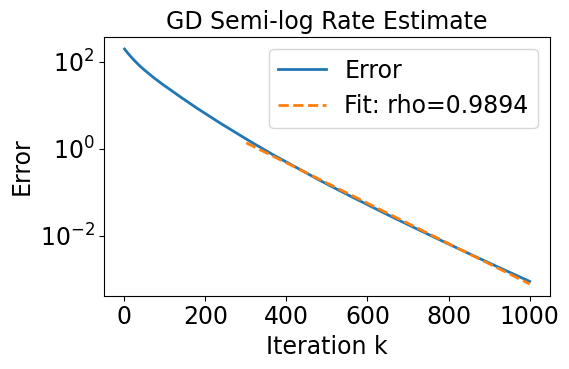

In [9]:
gd_rate = estimate_semilog_rate(
    error_hist=result_sgd["recon_error_hist"],
    start_ratio=0.3,
    end_ratio=1,
    method_name="GD",
    plot=True
)